# 04 – Born lensing and power spectrum

In this notebook we construct a spherical lightcone from an N-body
simulation and apply the Born approximation to obtain convergence
maps for a single source redshift. We then compare the measured
convergence power spectrum to a theoretical prediction.


## Imports & configuration
We configure JAX to run on CPU, import the public `fwd_model_tools`
API, and set up a moderately sized box and HEALPix resolution so the
example remains runnable on a single machine.


In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax_cosmo as jc
from scipy.stats import norm

from fwd_model_tools import (
    FieldStatus,
    DensityField,
    SphericalDensity,
    gaussian_initial_conditions,
    lpt,
    nbody,
    born,
    compute_lightcone_shells,
    compute_theory_cl,
    Planck18,
)

# Simulation setup
mesh_size = (64 , 64 , 64)
box_size = (4000.0, 4000.0, 4000.0)
observer_position = (0.5, 0.5, 0.5)
nside = 64
nb_shells = 10
flatsky_npix = (128, 128)

# N-body evolution parameters
t0 = 0.1
t1 = 1.0
dt0 = 0.05

key = jax.random.PRNGKey(42)
cosmo = Planck18()



/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound
ERROR:2025-11-19 18:40:55,072:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cud

## Gaussian initial conditions
We draw Gaussian initial conditions on the 3D mesh. The resulting
`DensityField` includes both flat-sky and spherical metadata for
later projections.


In [2]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    mesh_size=mesh_size,
    box_size=box_size,
    cosmo=cosmo,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)

print(gaussian_field)
print("Status:", gaussian_field.status)


DensityField(array=Array(64, 64, 64), mesh_size=(64, 64, 64), box_size=(4000.0, 4000.0, 4000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


z_centers = [0.3, 0.6]
gals/arcmin2 per bin: [7, 6.5]
Number of redshift bins: 2
Using first bin center z~=0.300 for theory curves
Mesh size: (64, 64, 64), box size: (4000.0, 4000.0, 4000.0) Mpc/h
nside=64, shells=10


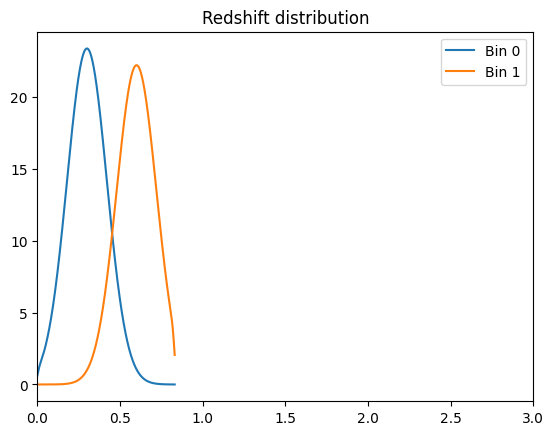

In [3]:
import matplotlib.pyplot as plt
# Source configuration
source_mode = "nz_shear"  # "point" or "nz_shear"
z_source = [0.3 , 0.6]
# Define nz_shear according to source_mode
if source_mode == "point":
    nz_shear = jnp.array(z_source)
    print(f"Using point source at z={z_source}")
elif source_mode == "nz_shear":
    max_redshift = jc.utils.a2z(jc.background.a_of_chi(cosmo , gaussian_field.max_comoving_radius)).squeeze()
    z_centers = z_source
    g = [7, 6.5]  # gals/arcmin2 per bin
    z = jnp.linspace(0, max_redshift, 1000)
    print(f"z_centers = {z_centers}")
    print(f"gals/arcmin2 per bin: {g}")

    nz_shear = [
        jc.redshift.kde_nz(
            z,
            norm.pdf(z, loc=z_center, scale=0.12),
            bw=0.01,
            zmax=max_redshift,
            gals_per_arcmin2=g,
        )
        for z_center, g in zip(z_centers, g)
    ]
    nbins = len(nz_shear)
    z_source_effective = float(z_centers[0])
    print(f"Number of redshift bins: {nbins}")
    print(f"Using first bin center z~={z_source_effective:.3f} for theory curves")
    for i in range(nbins):
        plt.plot(z, nz_shear[i](z)*nz_shear[i].gals_per_arcmin2, color='C%d'%i, label="Bin %d"%i)
    plt.legend()
    plt.xlim(0,3);
    plt.title('Redshift distribution')
else:
    raise ValueError(f"Unknown source_mode: {source_mode}")

print(f"Mesh size: {mesh_size}, box size: {box_size} Mpc/h")
print(f"nside={nside}, shells={nb_shells}")

## LPT initial displacements
We compute first-order LPT displacements and momenta at an initial
scale factor `t0`. These fields seed the N-body evolution.


In [4]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

max_radius = dx_field.max_comoving_radius
plane_width = dx_field.density_width(nb_shells)

print("Displacement field array shape:", dx_field.array.shape)
print(f"Max comoving radius: {max_radius:.1f} Mpc/h")
print(f"Density plane width: {plane_width:.1f} Mpc/h")


shape of initial force: (64, 64, 64, 3)
growth factor shape: (1,)
Displacement field array shape: (64, 64, 64, 3)
Max comoving radius: 2000.0 Mpc/h
Density plane width: 200.0 Mpc/h


## Shell centers and snapshot times
We construct radial shells that span the lightcone volume using
`compute_lightcone_shells`, which returns comoving shell centers and
corresponding scale factors.


In [5]:
r_center, ts = compute_lightcone_shells(
    cosmo=cosmo,
    field=gaussian_field,
    nb_shells=nb_shells,
)

print(
    f"Shell centers span {float(r_center[-1]):.1f}–{float(r_center[0]):.1f} Mpc/h"
)
print(
    f"Shell scale factors span {float(ts[-1]):.3f}–{float(ts[0]):.3f}"
)


Shell centers span 100.0–1900.0 Mpc/h
Shell scale factors span 0.967–0.562


## N-body lightcone (particle representation)
We evolve the system from `t0` to `t1` using the N-body integrator
and save snapshots at the shell scale factors `ts`. Using
`geometry="particles"` returns a stacked `ParticleField` with one
entry per shell.


In [6]:
particle_lightcone = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    ts=ts,
    geometry="particles",
)

print("Particle lightcone:", particle_lightcone)
print("Array shape:", particle_lightcone.array.shape)
print("Scale factors:", particle_lightcone.scale_factors)


Particle lightcone: ParticleField(array=Array(10, 64, 64, 64, 3), mesh_size=(64, 64, 64), box_size=(4000.0, 4000.0, 4000.0), status=lpt1, scale_factors_shape=(10,))
Array shape: (10, 64, 64, 64, 3)
Scale factors: [0.96732554 0.90672717 0.85174786 0.80113935 0.75432043 0.71056537
 0.67004627 0.63203595 0.59624785 0.56243902]


## Spherical lightcone via HEALPix painting
We now paint the particle lightcone onto a HEALPix sphere, obtaining
a `SphericalDensity` stack of shells ready to be used for Born
lensing.


In [7]:
spherical_lightcone = particle_lightcone.paint_spherical(
    center=r_center,
)

print(spherical_lightcone)
print("Lightcone array shape:", spherical_lightcone.array.shape)


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


SphericalDensity(array=Array(10, 49152), mesh_size=(64, 64, 64), box_size=(4000.0, 4000.0, 4000.0), status=lightcone, scale_factors_shape=(10,))
Lightcone array shape: (10, 49152)


## Visualize the spherical lightcone
We visualize a subset of the spherical shells in Mollweide projection
using the `show` helper.


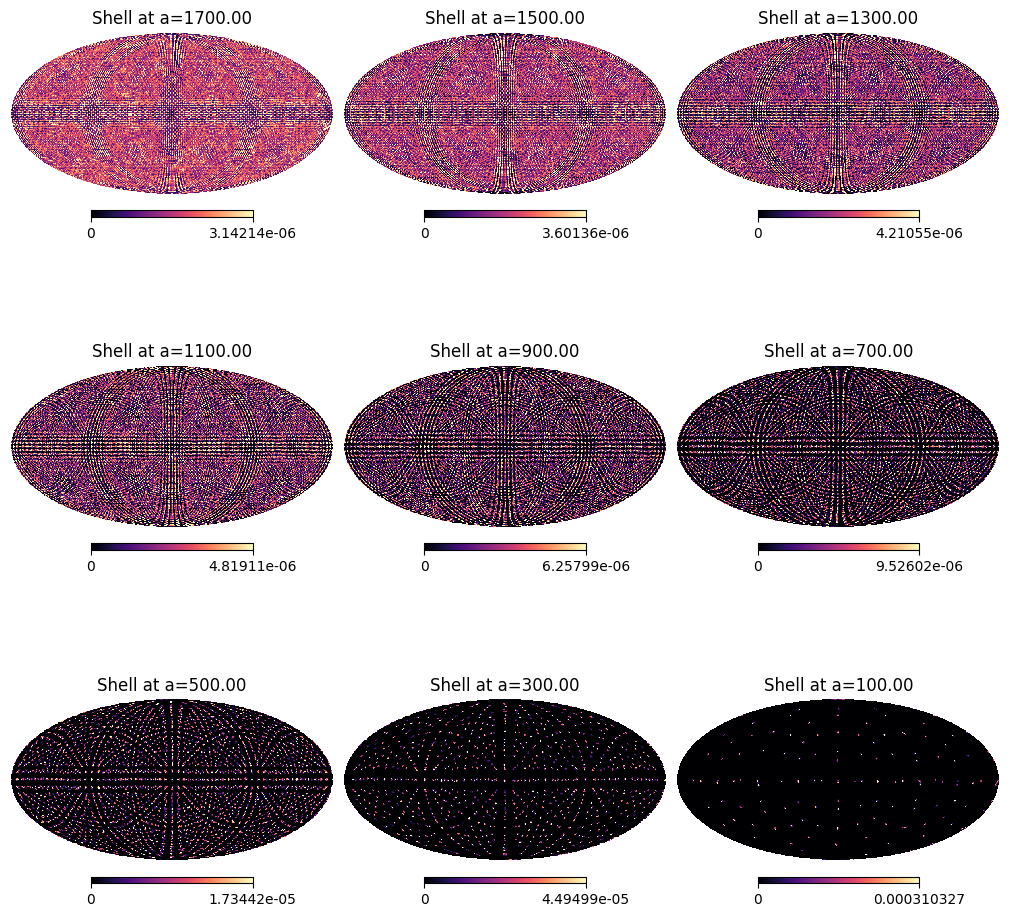

In [14]:
spherical_lightcone[-9:].show(
    ncols=3,
    figsize=(10, 10),
    titles=[f"Shell at a={r_center[i]:.2f}" for i in range(-9, 0)]
)


## Born convergence for a single source plane
We apply the Born approximation using the `born` function. Here we
use a delta-function source distribution at redshift `z_source`.


In [9]:
kappa_spherical = born(
    cosmo,
    spherical_lightcone,
    nz_shear=nz_shear,
    min_z=0.01,
    max_z=max_redshift if source_mode == "nz_shear" else z_source,
)

# born(...) can return a single SphericalKappaField or a list of them
if isinstance(kappa_spherical, list):
    print(f"Born returned {len(kappa_spherical)} convergence maps.")
    kappa_for_plots = kappa_spherical[0]
else:
    kappa_for_plots = kappa_spherical

# If the map stack has a leading bin axis, take the first map for plotting
if getattr(kappa_for_plots, "array", None) is not None and kappa_for_plots.array.ndim > 1:
    kappa_for_plots = kappa_for_plots[0]

print(kappa_for_plots)
print("kappa array shape:", kappa_for_plots.array.shape)


source_kind: distribution, sources: [(Array([0.        , 0.00083163, 0.00166325, 0.00249488, 0.0033265 ,
       0.00415813, 0.00498975, 0.00582138, 0.006653  , 0.00748463,
       0.00831625, 0.00914788, 0.00997951, 0.01081113, 0.01164276,
       0.01247438, 0.01330601, 0.01413763, 0.01496926, 0.01580088,
       0.01663251, 0.01746414, 0.01829576, 0.01912739, 0.01995901,
       0.02079064, 0.02162226, 0.02245389, 0.02328551, 0.02411714,
       0.02494876, 0.02578039, 0.02661202, 0.02744364, 0.02827527,
       0.02910689, 0.02993852, 0.03077014, 0.03160177, 0.03243339,
       0.03326502, 0.03409665, 0.03492827, 0.0357599 , 0.03659152,
       0.03742315, 0.03825477, 0.0390864 , 0.03991802, 0.04074965,
       0.04158127, 0.0424129 , 0.04324453, 0.04407615, 0.04490778,
       0.0457394 , 0.04657103, 0.04740265, 0.04823428, 0.0490659 ,
       0.04989753, 0.05072916, 0.05156078, 0.05239241, 0.05322403,
       0.05405566, 0.05488728, 0.05571891, 0.05655053, 0.05738216,
       0.05821378, 0.059

## Convergence map
We visualize the Born convergence map in Mollweide projection.


In [10]:
spherical_lightcone

SphericalDensity(array=Array(10, 49152), mesh_size=(64, 64, 64), box_size=(4000.0, 4000.0, 4000.0), status=lightcone, scale_factors_shape=(10,))

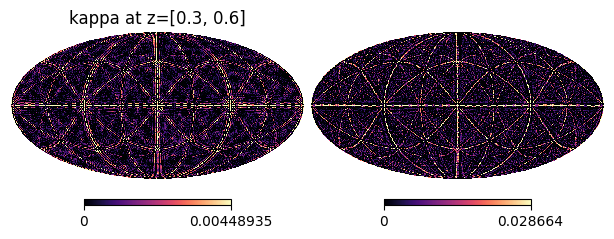

In [11]:
kappa_spherical.show(
    cmap="magma",
    apply_log=False,
    figsize=(6, 4),
    titles=[f"kappa at z={z_source}"],
)


## Power-spectrum comparison
We compute the measured convergence power spectrum and compare it to
`C_\ell` from `compute_theory_cl` for the same cosmology and source
redshift.


In [12]:
power_spectrum = kappa_for_plots.compute_power_spectrum()
ell_meas = jnp.asarray(power_spectrum.k)
cl_meas = jnp.asarray(power_spectrum.pk)

valid = ell_meas >= 2
ell_meas = ell_meas[valid]
cl_meas = cl_meas[valid]

ell_theory = jnp.arange(int(ell_meas[0]), int(ell_meas[-1]) + 1)
cl_theory = compute_theory_cl(cosmo, ell_theory, z_source=z_source_effective)
cl_interp = jnp.interp(ell_theory, ell_meas, cl_meas)


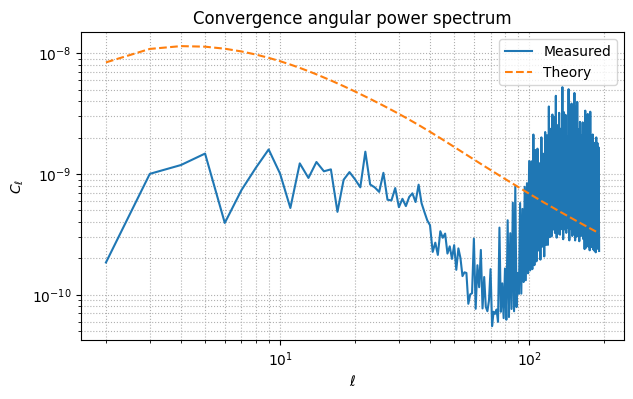

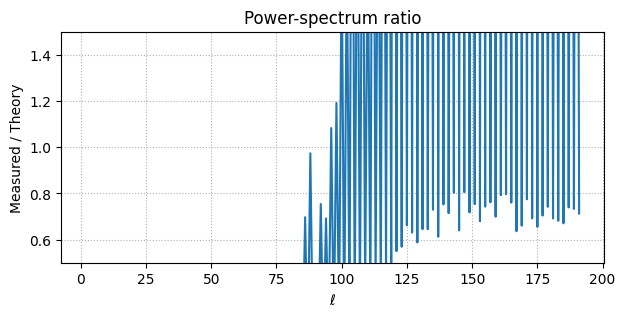

In [13]:
plt.figure(figsize=(7, 4))
plt.loglog(ell_meas, cl_meas, label="Measured")
plt.loglog(ell_theory, cl_theory, label="Theory", linestyle="--")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.title("Convergence angular power spectrum")
plt.legend()
plt.grid(True, which="both", linestyle=":")
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(ell_theory, cl_interp / cl_theory)
plt.xlabel(r"$\ell$")
plt.ylabel("Measured / Theory")
plt.title("Power-spectrum ratio")
plt.grid(True, linestyle=":")
plt.ylim(0.5, 1.5)
plt.show()


## Summary

In this notebook we:
- sampled Gaussian initial conditions on a 3D mesh,
- constructed an N-body spherical lightcone from particle snapshots,
- applied the Born approximation to obtain a convergence map for a
  single source redshift,
- and compared the measured convergence power spectrum to the
  corresponding theoretical prediction.

This Born-lensing validation closes the loop between the N-body
lightcone and large-scale weak-lensing observables.
